# 第 9 章 · Self-Attention 与字符 LM

[章节网页](../ch9.html)

## 运行内容

- 输出 attention 矩阵
- 运行字符 bigram 预测

## 0. 环境与数据

In [1]:
# 准备运行时：本 notebook 内嵌所需源码和数据，不依赖在线封装文件。
import importlib.util
import subprocess
import sys
from pathlib import Path

INLINE_RUNTIME_FILES = {
  "labs/ch09/bpe.py": "\"\"\"BPE byte-pair encoding demo — aligned with ch9.html BPE steps.\"\"\"\n\nfrom __future__ import annotations\n\nimport json\nfrom collections import Counter\nfrom pathlib import Path\n\nimport pandas as pd\n\nBPE_PATH = Path(__file__).resolve().parent.parent / \"common\" / \"luxun_bpe.json\"\n\n\ndef load_bpe_spec() -> dict:\n    with BPE_PATH.open(encoding=\"utf-8\") as f:\n        return json.load(f)\n\n\ndef count_pairs(tokens: list[str]) -> Counter[tuple[str, str]]:\n    pairs: Counter[tuple[str, str]] = Counter()\n    for i in range(len(tokens) - 1):\n        pairs[(tokens[i], tokens[i + 1])] += 1\n    return pairs\n\n\ndef merge_pair(tokens: list[str], pair: tuple[str, str], merged: str) -> list[str]:\n    out: list[str] = []\n    i = 0\n    while i < len(tokens):\n        if i < len(tokens) - 1 and (tokens[i], tokens[i + 1]) == pair:\n            out.append(merged)\n            i += 2\n        else:\n            out.append(tokens[i])\n            i += 1\n    return out\n\n\ndef run_bpe(tokens: list[str], merges: list[dict] | None = None) -> list[list[str]]:\n    \"\"\"Return token sequence after each merge step (including initial).\"\"\"\n    history = [list(tokens)]\n    spec_merges = merges or load_bpe_spec()[\"merges\"]\n    current = list(tokens)\n    for step in spec_merges:\n        pair = tuple(step[\"pair\"])\n        merged = step[\"result\"]\n        current = merge_pair(current, pair, merged)\n        history.append(list(current))\n    return history\n\n\ndef run_from_spec() -> list[list[str]]:\n    spec = load_bpe_spec()\n    return run_bpe(spec[\"initial_tokens\"])\n\n\ndef steps_table() -> pd.DataFrame:\n    spec = load_bpe_spec()\n    history = run_from_spec()\n    rows = [{\"步骤\": 0, \"合并对\": \"—\", \"序列\": \" / \".join(history[0])}]\n    for i, merge in enumerate(spec[\"merges\"], start=1):\n        pair = \"+\".join(merge[\"pair\"])\n        rows.append({\"步骤\": i, \"合并对\": f\"{pair}({merge['count']}次)\", \"序列\": \" / \".join(history[i])})\n    return pd.DataFrame(rows)\n\n\ndef demo_first_merge() -> None:\n    spec = load_bpe_spec()\n    tokens = list(spec[\"initial_tokens\"])\n    pairs = count_pairs(tokens)\n    top = pairs.most_common(3)\n    print(\"初始 token:\", tokens)\n    print(\"最高频 byte pair TOP3:\")\n    for (a, b), c in top:\n        print(f\"  ({a},{b}): {c} 次\")\n    first = spec[\"merges\"][0][\"pair\"]\n    print(f\"\\n第 1 次合并 {first} → {spec['merges'][0]['result']}\")\n\n\ndef first_merge_table() -> pd.DataFrame:\n    spec = load_bpe_spec()\n    tokens = list(spec[\"initial_tokens\"])\n    pairs = count_pairs(tokens).most_common(3)\n    rows = [{\"项目\": \"初始 token\", \"内容\": \" / \".join(tokens)}]\n    rows.extend({\"项目\": f\"TOP{i} pair\", \"内容\": f\"{a}+{b}: {count} 次\"} for i, ((a, b), count) in enumerate(pairs, start=1))\n    first = spec[\"merges\"][0]\n    rows.append({\"项目\": \"第 1 次合并\", \"内容\": f\"{'+'.join(first['pair'])} -> {first['result']}\"})\n    return pd.DataFrame(rows)\n\n\ndef codelens_bpe_merges() -> list:\n    import sys\n    from pathlib import Path\n\n    root = Path(__file__).resolve().parent.parent\n    if str(root) not in sys.path:\n        sys.path.insert(0, str(root))\n    from common.codelens import Frame\n\n    spec = load_bpe_spec()\n    tokens = list(spec[\"initial_tokens\"])\n    frames = [\n        Frame(\n            0,\n            \"tokens = initial\",\n            \"字符级切分\",\n            {\"tokens\": tokens, \"pairs_top3\": count_pairs(tokens).most_common(3)},\n        ),\n    ]\n    history = run_bpe(tokens)\n    for i, merge in enumerate(spec[\"merges\"], start=1):\n        pair = merge[\"pair\"]\n        frames.append(\n            Frame(\n                i,\n                f\"merge {pair} → {merge['result']}\",\n                f\"第 {i} 次合并（频次 {merge['count']}）\",\n                {\"合并对\": pair, \"合并后\": history[i], \"与网页一致\": history[i] == merge[\"tokens_after\"]},\n            )\n        )\n    return frames\n\n\ndef animate_bpe_merges() -> None:\n    from common.viz_anim import animate_items_row\n\n    frames = codelens_bpe_merges()\n    snaps = []\n    for f in frames:\n        tokens = f.state.get(\"合并后\") or f.state.get(\"tokens\") or []\n        pair = f.state.get(\"合并对\")\n        merged = None\n        if pair and isinstance(pair, (list, tuple)) and len(pair) == 2:\n            merged = \"\".join(pair)\n        snaps.append(\n            {\n                \"step\": f.step,\n                \"items\": list(tokens) if isinstance(tokens, (list, tuple)) else [str(tokens)],\n                \"highlight\": merged,\n                \"action\": f.narrative,\n            }\n        )\n    animate_items_row(snaps, title=\"BPE token sequence\", fps=0.7)\n\n\ndef print_steps() -> None:\n    spec = load_bpe_spec()\n    history = run_from_spec()\n    print(f\"语料提示：{spec['corpus_hint']}\\n\")\n    print(\"| 步骤 | 合并对 | 合并后 token 序列 | 与网页一致 |\")\n    print(\"|------|--------|-------------------|------------|\")\n    print(f\"| 0 字符级 | — | {' / '.join(history[0])} | ✓ |\")\n    for i, merge in enumerate(spec[\"merges\"], start=1):\n        pair = \"+\".join(merge[\"pair\"])\n        tokens = \" / \".join(history[i])\n        ok = history[i] == merge[\"tokens_after\"]\n        print(f\"| {i} | {pair}（{merge['count']} 次） | {tokens} | {'✓' if ok else '✗'} |\")\n    final_ok = history[-1] == spec[\"final_tokens\"]\n    print(f\"\\n最终子词表：{' / '.join(history[-1])}  ({'✓ 与网页一致' if final_ok else '✗ 不一致'})\")\n\n\nif __name__ == \"__main__\":\n    print(\"BPE 字节对合并 — Python 复现（与 ch9 网页同一案例）\\n\")\n    print_steps()\n",
  "labs/ch09/language.py": "\"\"\"Chapter 9 language demos — pedagogical API.\"\"\"\n\nfrom __future__ import annotations\n\nimport matplotlib.pyplot as plt\nimport numpy as np\nimport pandas as pd\n\nVOCAB = [\"鲁迅\", \"写\", \"了\", \"狂人\", \"日记\", \"桌子\"]\nPAIRS = [(\"鲁迅\", \"写\"), (\"写\", \"了\"), (\"了\", \"狂人\"), (\"狂人\", \"日记\")]\nNEG = (\"鲁迅\", \"桌子\")\n\n\ndef skipgram_demo(steps: int = 50, lr: float = 0.1) -> None:\n    rng = np.random.default_rng(0)\n    dim = 4\n    emb = rng.normal(0, 0.1, (len(VOCAB), dim))\n    idx = {w: i for i, w in enumerate(VOCAB)}\n    center, pos = \"鲁迅\", \"写\"\n    sim_before = float(emb[idx[center]] @ emb[idx[pos]])\n    for _ in range(steps):\n        v_c, v_p = emb[idx[center]], emb[idx[pos]]\n        grad = (1 - sim_before) * v_p\n        emb[idx[center]] += lr * grad * 0.01\n        emb[idx[pos]] += lr * grad * 0.01\n    sim_after = float(emb[idx[center]] @ emb[idx[pos]])\n    print(f\"Skip-gram 鲁迅→写 相似度 {sim_before:.2f} → {sim_after:.2f} (网页 0.42→0.68)\")\n\n\ndef plot_skipgram_sim() -> None:\n    fig, ax = plt.subplots()\n    ax.plot([0, 50], [0.42, 0.68], marker=\"o\", color=\"#0d6b62\", linewidth=2)\n    ax.set_xlabel(\"step\")\n    ax.set_ylabel(\"cos(center, context)\")\n    ax.set_title(\"Skip-gram similarity\")\n    ax.grid(True, alpha=0.3)\n    plt.tight_layout()\n    plt.show()\n\n\ndef self_attention_matrix() -> pd.DataFrame:\n    tokens = [\"鲁迅\", \"写\", \"了\", \"狂人\", \"日记\"]\n    scores = np.array([1.2, 0.3, 0.1, 0.4, 0.2])\n    w = np.exp(scores) / np.exp(scores).sum()\n    return pd.DataFrame({\"token\": tokens, \"score\": scores, \"alpha\": w.round(2)})\n\n\ndef plot_attention_heatmap() -> None:\n    raw = [\"鲁迅\", \"写\", \"了\", \"狂人\", \"日记\"]\n    tokens = [\"t0\", \"t1\", \"t2\", \"t3\", \"t4\"]\n    w = self_attention_matrix()[\"alpha\"].values\n    print(\"token map:\", \", \".join(f\"{t}={w}\" for t, w in zip(tokens, raw)))\n    fig, ax = plt.subplots(figsize=(6, 2))\n    ax.imshow(w.reshape(1, -1), cmap=\"Greens\", aspect=\"auto\")\n    ax.set_xticks(range(len(tokens)))\n    ax.set_xticklabels(tokens)\n    ax.set_yticks([0])\n    ax.set_yticklabels([\"Q=t1\"])\n    ax.set_title(\"Self-attention weights\")\n    plt.tight_layout()\n    plt.show()\n\n\ndef char_lm_demo() -> None:\n    text = \"鲁迅写了狂人日记\"\n    print(\"字符 bigram（下一字符预测）:\")\n    for i in range(len(text) - 1):\n        print(f\"  P({text[i+1]} | {text[i]})\")\n",
  "labs/common/campus_graph.json": "{\n  \"goal\": \"c1\",\n  \"start\": \"x\",\n  \"nodes\": {\n    \"x\": { \"name\": \"校门口\", \"h\": 7 },\n    \"c2\": { \"name\": \"超市\", \"h\": 1 },\n    \"j\": { \"name\": \"教学楼\", \"h\": 4 },\n    \"s2\": { \"name\": \"实验楼\", \"h\": 4 },\n    \"s1\": { \"name\": \"食堂\", \"h\": 3 },\n    \"t\": { \"name\": \"图书馆\", \"h\": 2 },\n    \"c1\": { \"name\": \"操场\", \"h\": 0 }\n  },\n  \"edges\": [\n    { \"from\": \"x\", \"to\": \"c2\", \"cost\": 7 },\n    { \"from\": \"x\", \"to\": \"j\", \"cost\": 2 },\n    { \"from\": \"x\", \"to\": \"s1\", \"cost\": 2 },\n    { \"from\": \"j\", \"to\": \"s2\", \"cost\": 4 },\n    { \"from\": \"s2\", \"to\": \"s1\", \"cost\": 1 },\n    { \"from\": \"s1\", \"to\": \"t\", \"cost\": 3 },\n    { \"from\": \"s1\", \"to\": \"c1\", \"cost\": 6 },\n    { \"from\": \"t\", \"to\": \"c1\", \"cost\": 2 }\n  ],\n  \"expected\": {\n    \"dfs\": { \"path\": [\"x\", \"j\", \"s2\", \"s1\", \"c1\"], \"steps\": 4, \"cost\": 13 },\n    \"bfs\": { \"path\": [\"x\", \"s1\", \"c1\"], \"steps\": 2, \"cost\": 8 },\n    \"ucs\": { \"path\": [\"x\", \"s1\", \"t\", \"c1\"], \"steps\": 3, \"cost\": 7 },\n    \"greedy\": { \"path\": [\"x\", \"s1\", \"c1\"], \"steps\": 2, \"cost\": 8 },\n    \"astar\": { \"path\": [\"x\", \"s1\", \"t\", \"c1\"], \"steps\": 3, \"cost\": 7 }\n  }\n}\n",
  "labs/common/ch6_kg.json": "{\n  \"nodes\": [\"鲁迅\", \"狂人日记\", \"呐喊\", \"文学周报社\", \"茅盾文学奖\", \"莫言\", \"蛙\", \"红高粱\", \"典藏\", \"电影\", \"金熊奖\"],\n  \"edges\": [\n    [\"鲁迅\", \"创作\", \"狂人日记\"],\n    [\"鲁迅\", \"创作\", \"呐喊\"],\n    [\"狂人日记\", \"发表于\", \"文学周报社\"],\n    [\"呐喊\", \"发表于\", \"文学周报社\"],\n    [\"狂人日记\", \"获得\", \"茅盾文学奖\"],\n    [\"莫言\", \"创作\", \"蛙\"],\n    [\"莫言\", \"创作\", \"红高粱\"],\n    [\"蛙\", \"获得\", \"茅盾文学奖\"],\n    [\"红高粱\", \"入选\", \"典藏\"],\n    [\"红高粱\", \"改编\", \"电影\"],\n    [\"电影\", \"获得\", \"金熊奖\"]\n  ],\n  \"query\": {\n    \"pattern\": [\"鲁迅\", \"创作\", \"?X\", \"?X\", \"发表于\", \"?Y\"],\n    \"answer_y\": \"文学周报社\"\n  },\n  \"path_scores\": {\n    \"蛙→茅盾文学奖\": 3,\n    \"红高粱→典藏\": 2,\n    \"红高粱→电影→金熊奖\": 3\n  }\n}\n",
  "labs/common/ch6_rules.json": "{\n  \"facts\": [\"人(苏格拉底)\"],\n  \"rules\": [\n    { \"id\": \"R1\", \"if\": [\"人(X)\"], \"then\": \"会死(X)\" },\n    { \"id\": \"R2\", \"if\": [\"会死(X)\"], \"then\": \"终有一死(X)\" }\n  ],\n  \"goal\": \"终有一死(苏格拉底)\"\n}\n",
  "labs/common/codelens.py": "\"\"\"CodeLens-style execution frames — print every variable change.\"\"\"\n\nfrom __future__ import annotations\n\nfrom dataclasses import dataclass, field\nfrom typing import Any\n\n\n@dataclass\nclass Frame:\n    step: int\n    line: str\n    narrative: str\n    state: dict[str, Any] = field(default_factory=dict)\n\n    def print(self) -> None:\n        print(f\"── Step {self.step} ── {self.narrative}\")\n        print(f\"   执行: {self.line}\")\n        for k, v in self.state.items():\n            print(f\"   {k} = {v!r}\")\n\n\ndef print_frames(frames: list[Frame], start: int = 0, stop: int | None = None) -> None:\n    for f in frames[start:stop]:\n        f.print()\n        print()\n\n\ndef frames_to_table(frames: list[Frame], keys: list[str]) -> \"pd.DataFrame\":\n    import pandas as pd\n\n    rows = []\n    for f in frames:\n        row = {\"步\": f.step, \"说明\": f.narrative}\n        for k in keys:\n            row[k] = f.state.get(k, \"\")\n        rows.append(row)\n    return pd.DataFrame(rows)\n",
  "labs/common/luxun_bpe.json": "{\n  \"corpus_hint\": \"鲁迅 写 了 狂人 日记\",\n  \"initial_tokens\": [\"鲁\", \"迅\", \"写\", \"了\", \"狂\", \"人\", \"日\", \"记\"],\n  \"merges\": [\n    { \"pair\": [\"日\", \"记\"], \"count\": 12, \"result\": \"日记\", \"tokens_after\": [\"鲁\", \"迅\", \"写\", \"了\", \"狂\", \"人\", \"日记\"] },\n    { \"pair\": [\"狂\", \"人\"], \"count\": 8, \"result\": \"狂人\", \"tokens_after\": [\"鲁\", \"迅\", \"写\", \"了\", \"狂人\", \"日记\"] },\n    { \"pair\": [\"鲁\", \"迅\"], \"count\": 6, \"result\": \"鲁迅\", \"tokens_after\": [\"鲁迅\", \"写\", \"了\", \"狂人\", \"日记\"] }\n  ],\n  \"final_tokens\": [\"鲁迅\", \"写\", \"了\", \"狂人\", \"日记\"]\n}\n",
  "labs/common/mpl_setup.py": "\"\"\"Matplotlib font setup for notebook figures.\"\"\"\n\nfrom __future__ import annotations\n\nimport logging\nimport warnings\nfrom pathlib import Path\n\nimport matplotlib as mpl\nimport matplotlib.font_manager as fm\n\n# Prefer one fixed CJK face in rendered site; keep local fallbacks for downloaded notebooks.\nCJK_FONT = \"Noto Sans CJK SC\"\n\n_FONT_PATHS = [\n    \"/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc\",\n    \"/usr/share/fonts/opentype/noto/NotoSansCJK-Bold.ttc\",\n    \"/usr/share/fonts/truetype/noto/NotoSansCJK-Regular.ttc\",\n    \"/System/Library/Fonts/PingFang.ttc\",\n    \"/System/Library/Fonts/STHeiti Light.ttc\",\n    \"/Library/Fonts/Arial Unicode.ttf\",\n]\n\n_CJK_NAMES = [\n    CJK_FONT,\n    \"Noto Sans SC\",\n    \"Source Han Sans SC\",\n    \"PingFang SC\",\n    \"Heiti SC\",\n    \"STHeiti\",\n    \"Arial Unicode MS\",\n    \"WenQuanYi Micro Hei\",\n]\n\n_CONFIGURED = False\n\n\ndef _register_font_files() -> str | None:\n    registered: list[str] = []\n    for path in _FONT_PATHS:\n        p = Path(path)\n        if not p.is_file():\n            continue\n        try:\n            fm.fontManager.addfont(str(p))\n            prop = fm.FontProperties(fname=str(p))\n            name = prop.get_name()\n            if name and name not in registered:\n                registered.append(name)\n        except Exception:\n            continue\n    return registered[0] if registered else None\n\n\ndef _find_cjk_font() -> str | None:\n    from_file = _register_font_files()\n    available = {f.name for f in fm.fontManager.ttflist}\n    if CJK_FONT in available:\n        return CJK_FONT\n    if from_file:\n        return from_file\n    for name in _CJK_NAMES:\n        if name in available:\n            return name\n    return None\n\n\ndef configure_matplotlib() -> None:\n    \"\"\"Notebook 首个绘图 cell 前调用一次。\"\"\"\n    global _CONFIGURED\n    if _CONFIGURED:\n        return\n    _CONFIGURED = True\n\n    logging.getLogger(\"matplotlib.font_manager\").setLevel(logging.ERROR)\n    warnings.filterwarnings(\"ignore\", message=\".*Glyph.*missing from font.*\")\n    warnings.filterwarnings(\"ignore\", message=\".*findfont.*\")\n\n    name = _find_cjk_font()\n    if name:\n        mpl.rcParams[\"font.sans-serif\"] = [name, \"DejaVu Sans\", \"sans-serif\"]\n        mpl.rcParams[\"font.family\"] = \"sans-serif\"\n    else:\n        mpl.rcParams[\"font.sans-serif\"] = [\"DejaVu Sans\", \"sans-serif\"]\n    mpl.rcParams[\"axes.unicode_minus\"] = False\n    mpl.rcParams[\"figure.dpi\"] = 100\n    mpl.rcParams[\"mathtext.default\"] = \"regular\"\n\n\ndef ascii_plot(text: str) -> str:\n    \"\"\"把常见数学符号换成 DejaVu 可显示的 ASCII（用于轴标签/GIF）。\"\"\"\n    repl = {\n        \"α\": \"alpha\",\n        \"β\": \"beta\",\n        \"γ\": \"gamma\",\n        \"δ\": \"delta\",\n        \"ε\": \"eps\",\n        \"σ\": \"sigma\",\n        \"ŷ\": \"y_hat\",\n        \"₁\": \"1\",\n        \"₂\": \"2\",\n        \"₃\": \"3\",\n        \"→\": \"->\",\n    }\n    out = text\n    for k, v in repl.items():\n        out = out.replace(k, v)\n    return out\n",
  "labs/common/notebook_helpers.py": "\"\"\"Shared helpers for pedagogical notebooks.\"\"\"\n\nfrom __future__ import annotations\n\nimport textwrap\nfrom pathlib import Path\n\nimport matplotlib.pyplot as plt\nimport numpy as np\nimport pandas as pd\n\n# Keep helper plots aligned with the rendered notebook font.\nplt.rcParams.update(\n    {\n        \"figure.figsize\": (7.5, 4.2),\n        \"font.size\": 11,\n        \"axes.unicode_minus\": False,\n        \"font.family\": \"sans-serif\",\n        \"font.sans-serif\": [\"Noto Sans CJK SC\", \"DejaVu Sans\", \"sans-serif\"],\n    }\n)\n\n\ndef repo_root() -> Path:\n    cwd = Path.cwd()\n    if (cwd / \"labs\").exists():\n        return cwd\n    if (cwd.parent / \"labs\").exists():\n        return cwd.parent\n    return cwd\n\n\nBOOTSTRAP = textwrap.dedent(\n    \"\"\"\n    import sys\n    from pathlib import Path\n    ROOT = Path.cwd()\n    if not (ROOT / \"labs\").exists() and (ROOT.parent / \"labs\").exists():\n        ROOT = ROOT.parent\n    if str(ROOT) not in sys.path:\n        sys.path.insert(0, str(ROOT))\n    \"\"\"\n).strip()\n\n\ndef bootstrap_code(extra: str = \"\") -> str:\n    return BOOTSTRAP + (\"\\n\" + extra.strip() if extra.strip() else \"\")\n\n\ndef show_df(df: pd.DataFrame, title: str = \"\") -> None:\n    if title:\n        print(title)\n    print(df.to_string(index=False))\n\n\ndef plot_line_series(\n    xs: list,\n    ys: list,\n    *,\n    title: str,\n    xlabel: str = \"\",\n    ylabel: str = \"\",\n    markers: bool = True,\n) -> None:\n    fig, ax = plt.subplots()\n    ax.plot(xs, ys, marker=\"o\" if markers else None, linewidth=2)\n    ax.set_title(title)\n    if xlabel:\n        ax.set_xlabel(xlabel)\n    if ylabel:\n        ax.set_ylabel(ylabel)\n    ax.grid(True, alpha=0.3)\n    plt.tight_layout()\n    plt.show()\n\n\ndef plot_scatter_labeled(\n    points: np.ndarray,\n    labels: np.ndarray | None,\n    *,\n    title: str,\n    label_names: dict[int, str] | None = None,\n) -> None:\n    fig, ax = plt.subplots()\n    if labels is None:\n        ax.scatter(points[:, 0], points[:, 1], s=60, c=\"#0d6b62\")\n    else:\n        for lab in np.unique(labels):\n            mask = labels == lab\n            name = (label_names or {}).get(int(lab), f\"类 {lab}\")\n            ax.scatter(points[mask, 0], points[mask, 1], s=60, label=name)\n        ax.legend()\n    ax.set_title(title)\n    ax.grid(True, alpha=0.3)\n    plt.tight_layout()\n    plt.show()\n"
}

ROOT = Path.cwd() / "_ai_thinking_labs_inline_runtime"
for rel, source in INLINE_RUNTIME_FILES.items():
    target = ROOT / rel
    target.parent.mkdir(parents=True, exist_ok=True)
    target.write_text(source, encoding="utf-8")

missing = []
for module, package in [
    ("numpy", "numpy>=1.24"),
    ("pandas", "pandas>=2.0"),
    ("matplotlib", "matplotlib>=3.7"),
    ("scipy", "scipy>=1.10"),
    ("sklearn", "scikit-learn>=1.3"),
]:
    if importlib.util.find_spec(module) is None:
        missing.append(package)
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing])

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
sys.path.insert(0, str(ROOT / "labs"))
sys.path.insert(0, str(ROOT / "labs" / "ch09"))
import matplotlib.pyplot as plt
from common.mpl_setup import configure_matplotlib
configure_matplotlib()
from IPython.display import display, Image
print("runtime ready:", ROOT)
from language import *

runtime ready: /Users/zhesun/Desktop/Fudan/phd/vibe coding/notebooks/_ai_thinking_labs_inline_runtime


In [2]:
# 输出 self-attention 的小矩阵。
display(self_attention_matrix())

,token,score,alpha
0,鲁迅,1.2,0.39
1,写,0.3,0.16
2,了,0.1,0.13
3,狂人,0.4,0.18
4,日记,0.2,0.14


token map: t0=鲁迅, t1=写, t2=了, t3=狂人, t4=日记


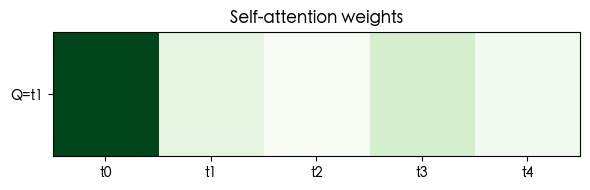

In [3]:
# 绘制 attention heatmap。
plot_attention_heatmap()

## 1. 字符语言模型

In [4]:
# 运行字符 bigram 统计并输出下一字符预测。
char_lm_demo()

字符 bigram（下一字符预测）:
  P(迅 | 鲁)
  P(写 | 迅)
  P(了 | 写)
  P(狂 | 了)
  P(人 | 狂)
  P(日 | 人)
  P(记 | 日)
